# RideWise — Exploratory Data Analysis (EDA)

Understand the shape, quality, and patterns in every dataset before modelling.

## Step 1 · Setup & Imports

In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline

PALETTE = ["#2D6A4F", "#52B788", "#95D5B2", "#D8F3DC", "#B7E4C7"]
ACCENT  = "#1B4332"
BLUE    = "#264653"
ORANGE  = "#E9C46A"
RED     = "#E76F51"

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": plt.cycler(color=PALETTE),
})
print("Libraries loaded ✓")


Libraries loaded ✓


## Step 2 · Load Datasets

In [2]:
DATA_RAW = ".."   # CSVs are one folder above the Notebooks folder

riders     = pd.read_csv(os.path.join(DATA_RAW, "riders.csv"),     parse_dates=["signup_date"])
trips      = pd.read_csv(os.path.join(DATA_RAW, "trips.csv"))
drivers    = pd.read_csv(os.path.join(DATA_RAW, "drivers.csv"),    parse_dates=["signup_date"])
sessions   = pd.read_csv(os.path.join(DATA_RAW, "sessions.csv"))
promotions = pd.read_csv(os.path.join(DATA_RAW, "promotions.csv"))

for name, df in [("riders", riders), ("trips", trips), ("drivers", drivers),
                 ("sessions", sessions), ("promotions", promotions)]:
    print(f"  {name:<12} {df.shape[0]:>7,} rows  {df.shape[1]:>2} cols")


  riders        10,000 rows   8 cols
  trips        200,000 rows  16 cols
  drivers        5,000 rows   7 cols
  sessions      50,000 rows   8 cols
  promotions        20 rows  11 cols


### 2a · Data Types & Null Check

In [3]:
for name, df in [("riders", riders), ("trips", trips), ("drivers", drivers), ("sessions", sessions)]:
    nulls = df.isnull().sum()
    if nulls.any():
        print(f"\n── {name} nulls ──")
        print(nulls[nulls > 0])
    else:
        print(f"\n── {name}: no nulls ──")



── riders nulls ──
referred_by    6947
dtype: int64

── trips: no nulls ──

── drivers: no nulls ──

── sessions: no nulls ──


### 2b · Sample Rows

In [4]:
riders.head()

,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,NaN
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,NaN
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002


In [5]:
trips.head()

,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,city,loyalty_status
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,36.912209,-1.068155,36.875377,Foggy,Nairobi,Bronze
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 23:13:48+00:14,2024-10-28 23:26:48+00:14,6.675266,3.515740,6.641734,3.525620,Sunny,Lagos,Gold
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 05:36:41+02:27,2025-02-17 05:52:41+02:27,-1.248589,37.010668,-1.273182,37.018586,Cloudy,Nairobi,Bronze
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 19:27:14+02:05,2024-06-18 19:32:14+02:05,29.819554,31.188780,29.837689,31.232978,Cloudy,Cairo,Bronze
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 09:58:16+02:27,2024-10-05 10:28:16+02:27,-1.676479,36.729219,-1.638395,36.694063,Sunny,Nairobi,Gold


## Step 3 · Rider Demographics

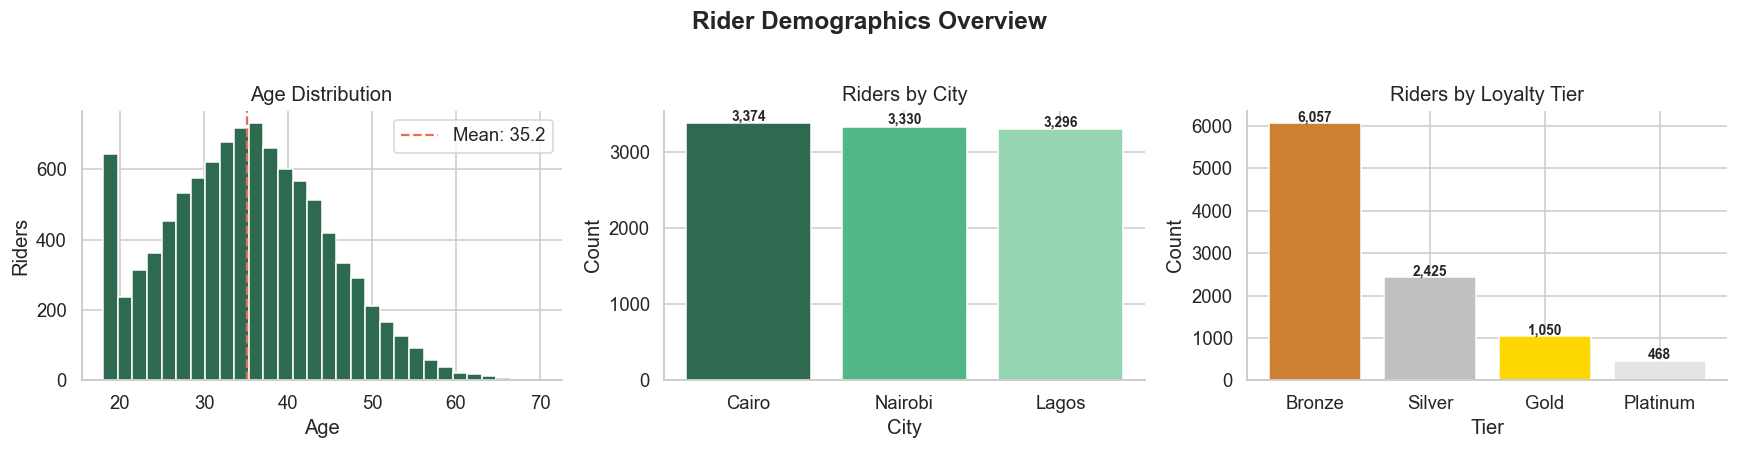

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age distribution
axes[0].hist(riders["age"].dropna(), bins=30, color=PALETTE[0], edgecolor="white")
axes[0].axvline(riders["age"].mean(), color=RED, linestyle="--",
                label=f'Mean: {riders["age"].mean():.1f}')
axes[0].set(title="Age Distribution", xlabel="Age", ylabel="Riders")
axes[0].legend()

# City distribution
city_counts = riders["city"].value_counts()
bars = axes[1].bar(city_counts.index, city_counts.values,
                   color=PALETTE[:len(city_counts)], edgecolor="white")
for bar, v in zip(bars, city_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 40,
                 f"{v:,}", ha="center", fontsize=9, fontweight="bold")
axes[1].set(title="Riders by City", xlabel="City", ylabel="Count")

# Loyalty distribution
order = ["Bronze", "Silver", "Gold", "Platinum"]
loy = riders["loyalty_status"].value_counts().reindex(order)
bars2 = axes[2].bar(loy.index, loy.values,
                    color=["#CD7F32","#C0C0C0","#FFD700","#E5E4E2"], edgecolor="white")
for bar, v in zip(bars2, loy.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 40,
                 f"{v:,}", ha="center", fontsize=9, fontweight="bold")
axes[2].set(title="Riders by Loyalty Tier", xlabel="Tier", ylabel="Count")

plt.suptitle("Rider Demographics Overview", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Step 4 · Churn Probability Distribution

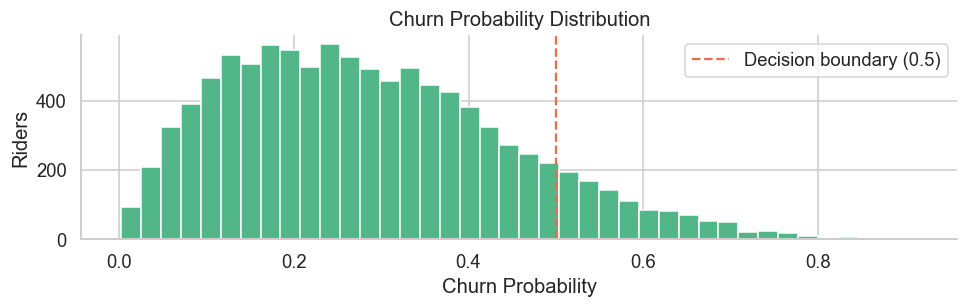

Riders with churn_prob > 0.5: 1,063


In [7]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(riders["churn_prob"].dropna(), bins=40, color=PALETTE[1], edgecolor="white")
ax.axvline(0.5, color=RED, linestyle="--", linewidth=1.5, label="Decision boundary (0.5)")
ax.set(title="Churn Probability Distribution", xlabel="Churn Probability", ylabel="Riders")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Riders with churn_prob > 0.5: {(riders['churn_prob'] > 0.5).sum():,}")


## Step 5 · Signup Trend Over Time

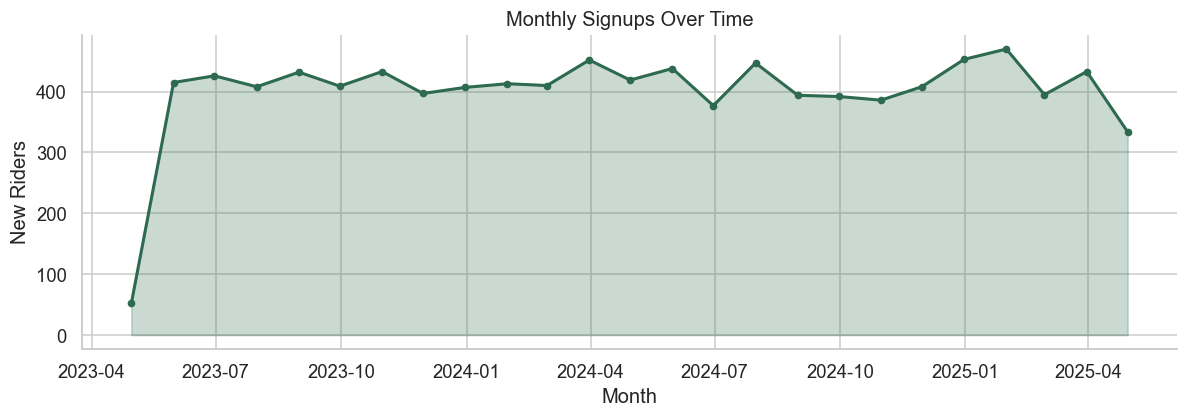

In [8]:
monthly = (riders.set_index("signup_date").resample("ME").size().reset_index(name="signups"))

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(monthly["signup_date"], monthly["signups"], alpha=0.25, color=PALETTE[0])
ax.plot(monthly["signup_date"], monthly["signups"],
        marker="o", color=PALETTE[0], linewidth=2, markersize=4)
ax.set(title="Monthly Signups Over Time", xlabel="Month", ylabel="New Riders")
plt.tight_layout()
plt.show()


## Step 6 · Trips Analysis

In [9]:
for col in ["pickup_time", "dropoff_time"]:
    trips[col] = pd.to_datetime(trips[col], utc=True).dt.tz_convert(None)

trips = trips.dropna(subset=["pickup_time", "dropoff_time"])
trips["trip_duration_min"] = (trips["dropoff_time"] - trips["pickup_time"]).dt.total_seconds() / 60
trips["total_revenue"]     = trips["fare"] * trips["surge_multiplier"] + trips["tip"].fillna(0)
trips["hour_of_day"]       = trips["pickup_time"].dt.hour
trips["day_of_week"]       = trips["pickup_time"].dt.day_name()
trips = trips[trips["trip_duration_min"] > 0]

print(f"Clean trips: {len(trips):,}")
trips.describe()[["fare", "surge_multiplier", "trip_duration_min", "total_revenue"]]


Clean trips: 200,000


,fare,surge_multiplier,trip_duration_min,total_revenue
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,15.401285,1.141500,31.957310,18.927551
min,2.970000,1.000000,5.000000,2.970000
25%,11.000000,1.000000,18.000000,11.600000
50%,14.130000,1.000000,32.000000,15.450000
75%,18.350000,1.200000,46.000000,21.740000
max,82.740000,3.800000,59.000000,263.654000
std,6.163199,0.255362,15.871754,12.077398


### 6a · Financial & Duration Distributions

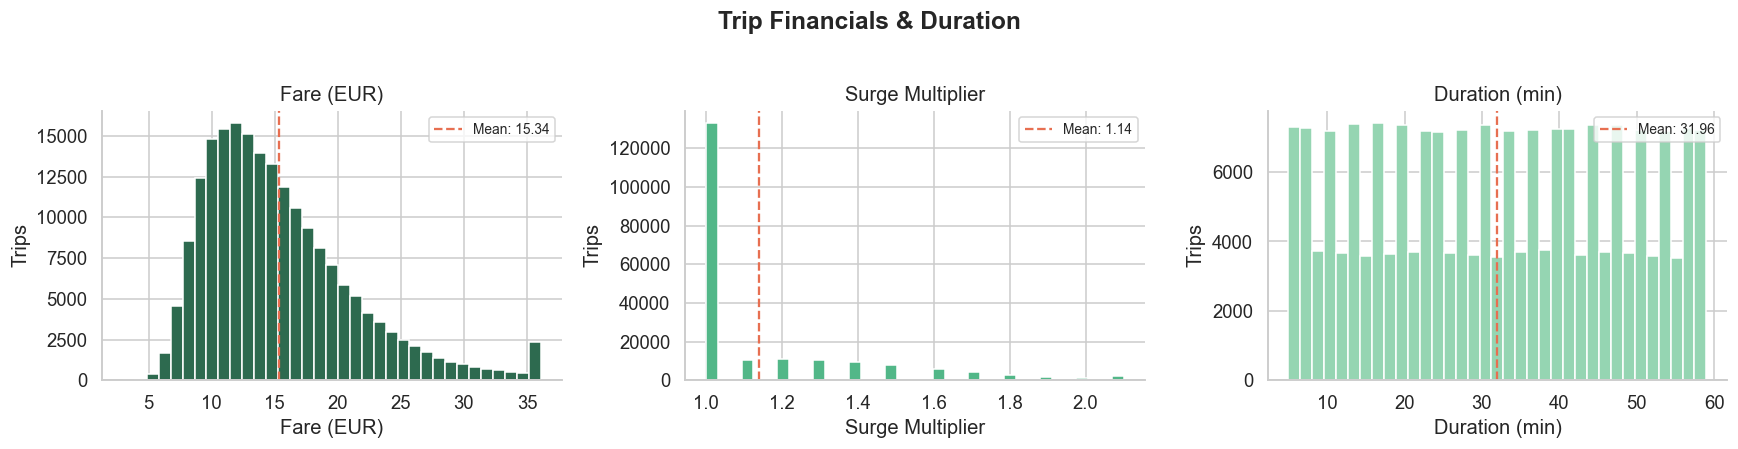

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

specs = [
    ("fare",             "Fare (EUR)",        PALETTE[0]),
    ("surge_multiplier", "Surge Multiplier",  PALETTE[1]),
    ("trip_duration_min","Duration (min)",    PALETTE[2]),
]

for ax, (col, title, color) in zip(axes, specs):
    data = trips[col].clip(upper=trips[col].quantile(0.99)).dropna()
    ax.hist(data, bins=35, color=color, edgecolor="white")
    ax.axvline(data.mean(), color=RED, linestyle="--", label=f"Mean: {data.mean():.2f}")
    ax.set(title=title, xlabel=title, ylabel="Trips")
    ax.legend(fontsize=9)

plt.suptitle("Trip Financials & Duration", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 6b · When Do People Ride?

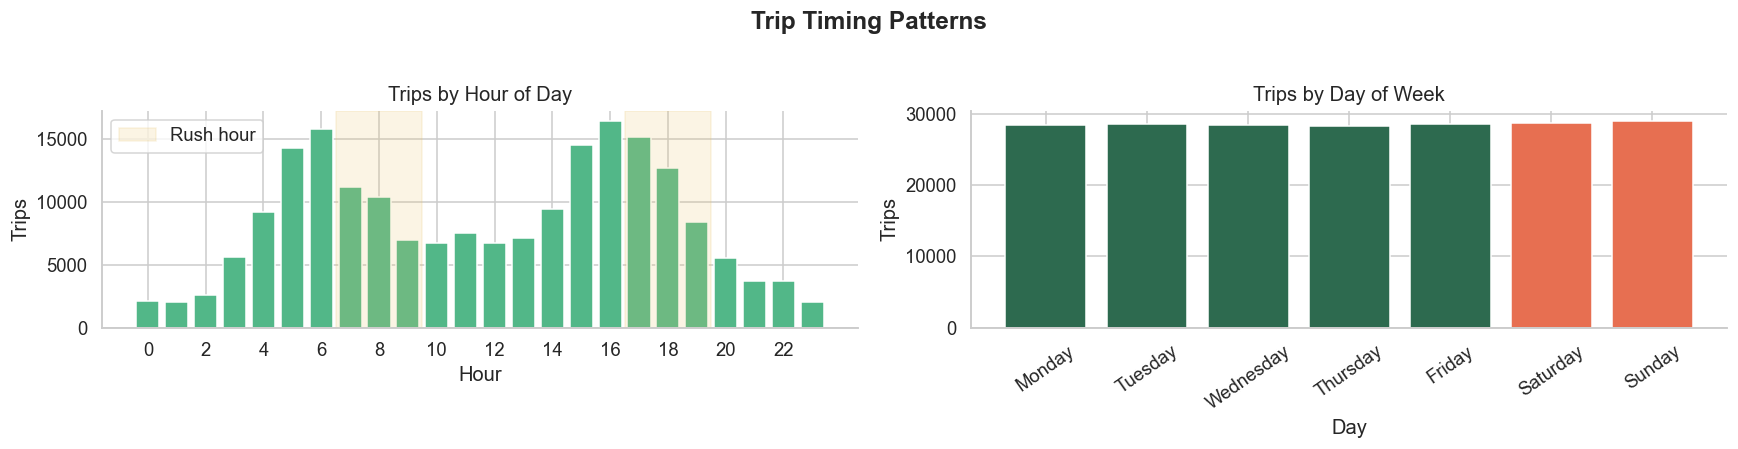

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Hour of day
hour_counts = trips["hour_of_day"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color=PALETTE[1], edgecolor="white")
axes[0].axvspan(6.5, 9.5,  alpha=0.18, color=ORANGE, label="Rush hour")
axes[0].axvspan(16.5, 19.5, alpha=0.18, color=ORANGE)
axes[0].set(title="Trips by Hour of Day", xlabel="Hour", ylabel="Trips")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

# Day of week
day_order  = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_colors = [PALETTE[0]] * 5 + [RED, RED]
day_counts = trips["day_of_week"].value_counts().reindex(day_order)
axes[1].bar(day_order, day_counts.values, color=day_colors, edgecolor="white")
axes[1].set(title="Trips by Day of Week", xlabel="Day", ylabel="Trips")
axes[1].tick_params(axis="x", rotation=35)

plt.suptitle("Trip Timing Patterns", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 6c · Payment Type & Weather

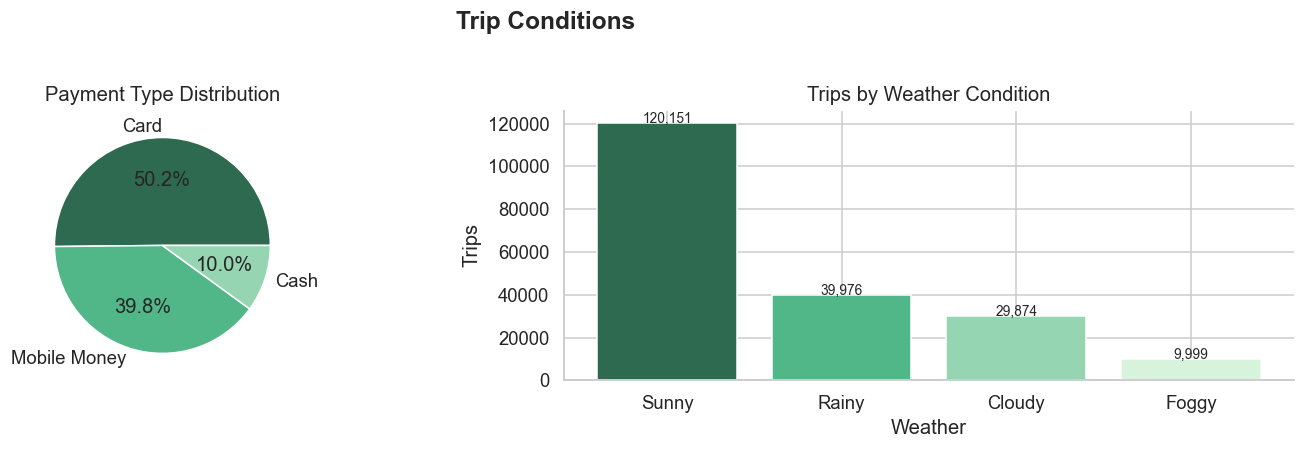

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pay = trips["payment_type"].value_counts()
axes[0].pie(pay.values, labels=pay.index, autopct="%1.1f%%",
            colors=PALETTE[:len(pay)], wedgeprops={"edgecolor": "white"})
axes[0].set_title("Payment Type Distribution")

weather = trips["weather"].value_counts()
bars = axes[1].bar(weather.index, weather.values,
                   color=PALETTE[:len(weather)], edgecolor="white")
for bar, v in zip(bars, weather.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 200,
                 f"{v:,}", ha="center", fontsize=9)
axes[1].set(title="Trips by Weather Condition", xlabel="Weather", ylabel="Trips")

plt.suptitle("Trip Conditions", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Step 7 · Driver Fleet Analysis

In [13]:
print(f"Shape: {drivers.shape}")
print(drivers.isnull().sum())


Shape: (5000, 7)
driver_id          0
rating             0
vehicle_type       0
signup_date        0
last_active        0
city               0
acceptance_rate    0
dtype: int64


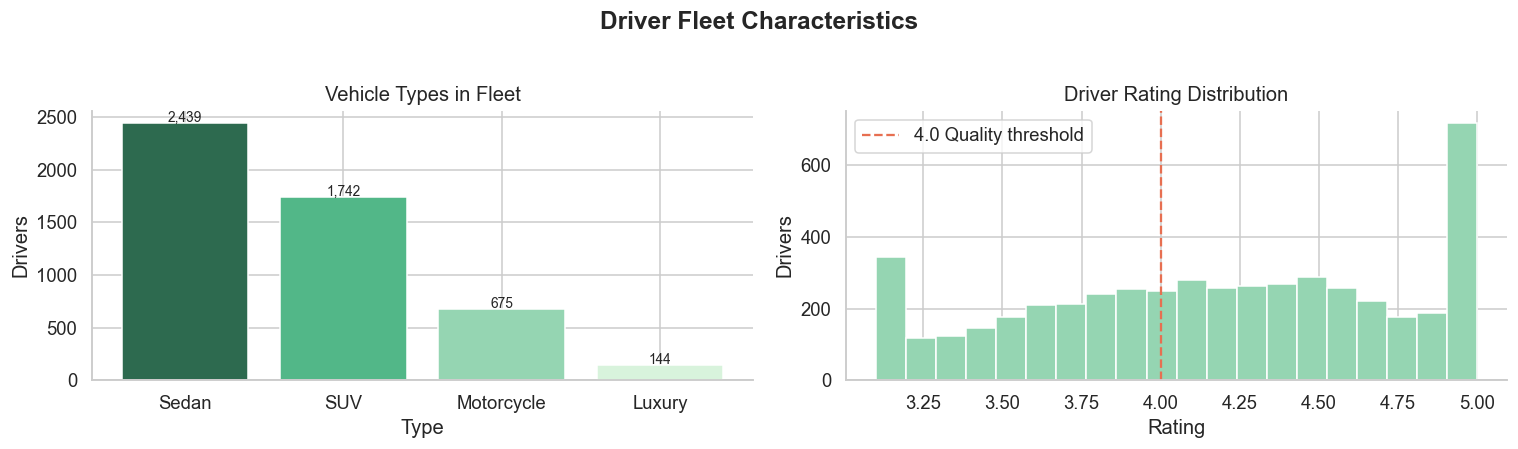

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vc = drivers["vehicle_type"].value_counts()
bars = axes[0].bar(vc.index, vc.values, color=PALETTE[:len(vc)], edgecolor="white")
for bar, v in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 10,
                 f"{v:,}", ha="center", fontsize=9)
axes[0].set(title="Vehicle Types in Fleet", xlabel="Type", ylabel="Drivers")

axes[1].hist(drivers["rating"].dropna(), bins=20, color=PALETTE[2], edgecolor="white")
axes[1].axvline(4.0, color=RED, linestyle="--", linewidth=1.5, label="4.0 Quality threshold")
axes[1].set(title="Driver Rating Distribution", xlabel="Rating", ylabel="Drivers")
axes[1].legend()

plt.suptitle("Driver Fleet Characteristics", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Step 8 · Session Analysis

In [15]:
sessions["session_time"] = pd.to_datetime(sessions["session_time"], utc=True).dt.tz_convert(None)
sessions = sessions.dropna(subset=["session_time"])
print(f"Shape: {sessions.shape}")
sessions.head()


Shape: (50000, 8)


,session_id,rider_id,session_time,time_on_app,pages_visited,converted,city,loyalty_status
0,S000000,R08605,2025-04-27 16:52:06,79,4,1,Cairo,Bronze
1,S000001,R08823,2025-04-27 05:05:22,101,3,0,Nairobi,Silver
2,S000002,R05342,2025-04-27 21:12:25,12,1,0,Cairo,Bronze
3,S000003,R05057,2025-04-27 14:26:25,19,1,0,Lagos,Silver
4,S000004,R09614,2025-04-27 08:17:22,4,1,0,Lagos,Bronze


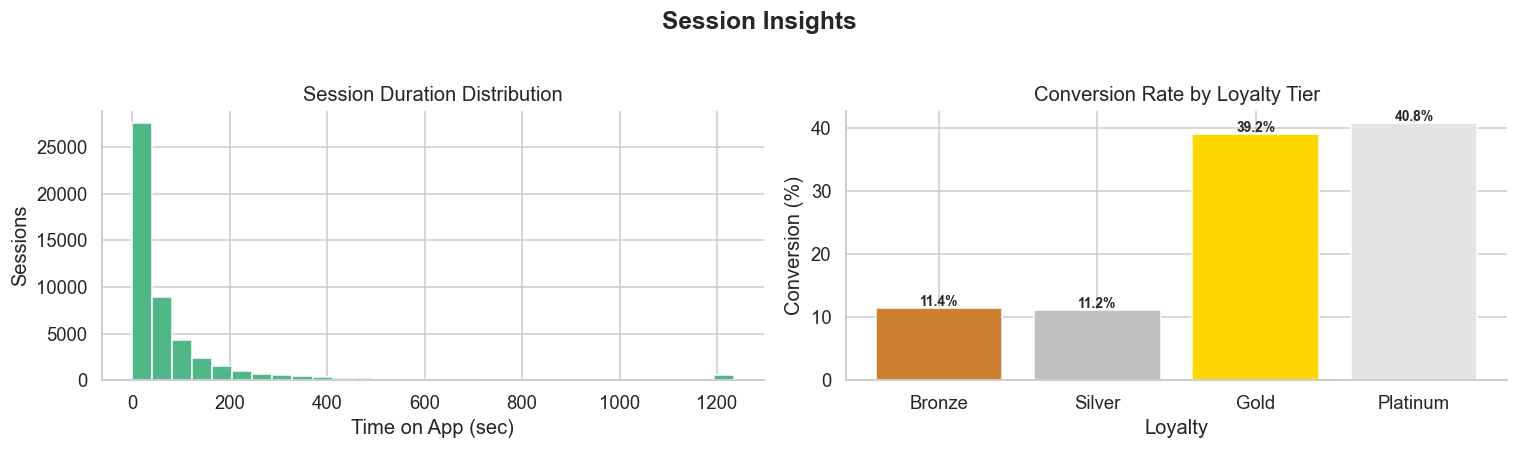

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(
    sessions["time_on_app"].clip(upper=sessions["time_on_app"].quantile(0.99)).dropna(),
    bins=30, color=PALETTE[1], edgecolor="white")
axes[0].set(title="Session Duration Distribution", xlabel="Time on App (sec)", ylabel="Sessions")

conv = sessions.groupby("loyalty_status")["converted"].mean().mul(100)
loy_order = [l for l in ["Bronze","Silver","Gold","Platinum"] if l in conv.index]
conv = conv.reindex(loy_order)
bars = axes[1].bar(conv.index, conv.values,
                   color=["#CD7F32","#C0C0C0","#FFD700","#E5E4E2"][:len(conv)], edgecolor="white")
for bar, v in zip(bars, conv.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
axes[1].set(title="Conversion Rate by Loyalty Tier", xlabel="Loyalty", ylabel="Conversion (%)")

plt.suptitle("Session Insights", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Step 9 · Churn Analysis

In [17]:
riders["churned"] = (riders["churn_prob"] >= 0.5).astype(int)
print(f"Overall churn rate : {riders['churned'].mean() * 100:.1f}%")
print(f"Churned riders     : {riders['churned'].sum():,}")
print(f"Retained riders    : {(riders['churned'] == 0).sum():,}")


Overall churn rate : 10.6%
Churned riders     : 1,063
Retained riders    : 8,937


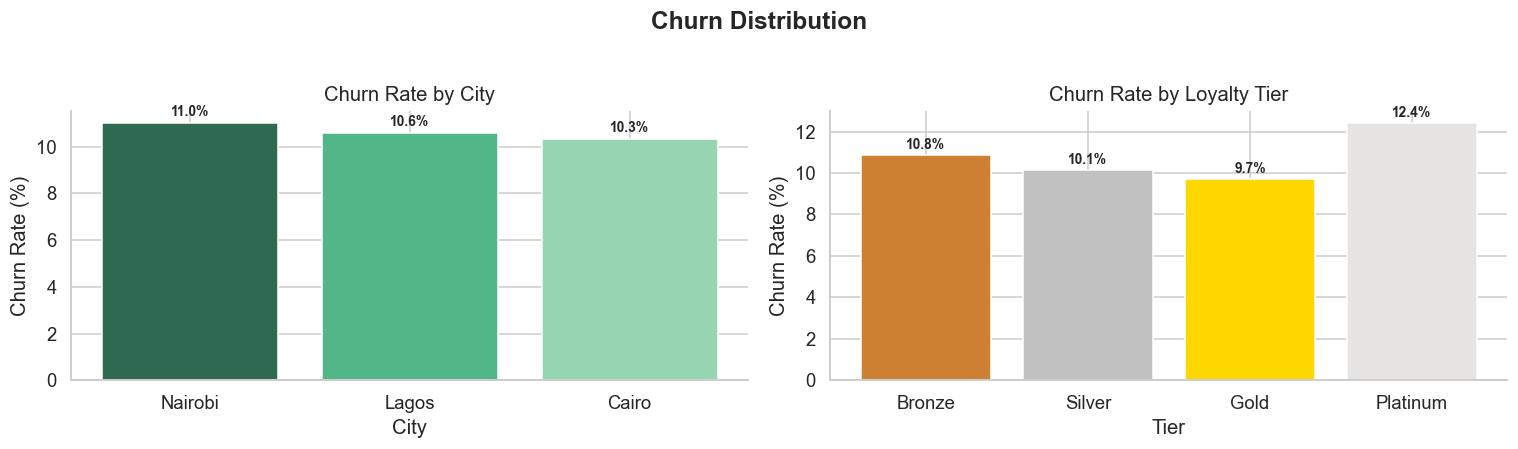

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

city_churn = riders.groupby("city")["churned"].mean().mul(100).sort_values(ascending=False)
bars = axes[0].bar(city_churn.index, city_churn.values,
                   color=PALETTE[:len(city_churn)], edgecolor="white")
for bar, v in zip(bars, city_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
axes[0].set(title="Churn Rate by City", xlabel="City", ylabel="Churn Rate (%)")

loy_churn = (riders.groupby("loyalty_status")["churned"].mean().mul(100)
             .reindex(["Bronze","Silver","Gold","Platinum"]))
bars2 = axes[1].bar(loy_churn.index, loy_churn.values,
                    color=["#CD7F32","#C0C0C0","#FFD700","#E5E4E2"], edgecolor="white")
for bar, v in zip(bars2, loy_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
axes[1].set(title="Churn Rate by Loyalty Tier", xlabel="Tier", ylabel="Churn Rate (%)")

plt.suptitle("Churn Distribution", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Key Takeaways
- Cities: **Nairobi, Lagos, Cairo**
- ~10% of riders have churn probability ≥ 0.5
- Rush hours (7–9 AM, 5–7 PM) drive peak trip volume
- Lower loyalty tiers show higher churn rates